<a href="https://colab.research.google.com/github/ayslanleal/esc-classification-mlp/blob/main/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [3]:
MFCC_CONFIGS = [
    "mfcc20_flatten", "mfcc15_flatten", "mfcc13_flatten",
    "mfcc10_flatten", "mfcc5_flatten",
    "mfcc20_mean",    "mfcc15_mean",    "mfcc13_mean",
    "mfcc10_mean",    "mfcc5_mean",
]

N_CLASSES = 12

In [10]:
def encode_labels(df: pd.DataFrame, label_col: str = "label"):
    le = LabelEncoder()
    y = le.fit_transform(df[label_col].values)
    return y, le


def build_mlp(input_dim: int, n_classes: int = N_CLASSES) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,))
    x = Dense(256, activation="relu")(inputs)
    x = Dense(128, activation="relu")(x)
    x = Dense(64,  activation="relu")(x)
    outputs = Dense(n_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def get_hidden_features(model: tf.keras.Model, X: np.ndarray) -> np.ndarray:
    hidden_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.layers[-2].output
    )
    return hidden_model.predict(X, verbose=0)


def plot_tsne(features: np.ndarray, labels: np.ndarray, le: LabelEncoder, title: str):
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(features)

    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(le.classes_):
        mask = labels == i
        plt.scatter(proj[mask, 0], proj[mask, 1], label=cls, s=20)

    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    return proj

def run_experiment(
    df: pd.DataFrame,
    config_col: str,
    y_encoded: np.ndarray,
    le: LabelEncoder,
    epochs: int = 100,
) -> dict:

    vectors = df[config_col].values
    max_len = max(v.shape[0] for v in vectors)
    vectors_padded = np.array([
        np.pad(v, (0, max_len - v.shape[0])) for v in vectors
    ])

    # 80/20
    X = vectors_padded
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    model = build_mlp(input_dim=X_train.shape[1])
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        validation_data=(X_test, y_test),
        verbose=0,
    )

    _, accuracy = model.evaluate(X_test, y_test, verbose=0)

    train_hidden = get_hidden_features(model, X_train)
    test_hidden  = get_hidden_features(model, X_test)

    # t-SNE e silhueta — treino
    train_proj = plot_tsne(train_hidden, y_train, le, title=f"t-SNE Treino | {config_col}")
    silhouette_train = silhouette_score(train_proj, y_train)

    # t-SNE e silhueta — teste
    test_proj = plot_tsne(test_hidden, y_test, le, title=f"t-SNE Teste | {config_col}")
    silhouette_test = silhouette_score(test_proj, y_test)

    print(f"[{config_col}] Acurácia: {accuracy:.4f} | Silhueta treino: {silhouette_train:.4f} | Silhueta teste: {silhouette_test:.4f}")

    return {
        "config":           config_col,
        "accuracy":         accuracy,
        "silhouette_train": silhouette_train,
        "silhouette_test":  silhouette_test,
        "history":          history,
    }


def run_all_experiments(
    df: pd.DataFrame,
    label_col: str = "label",
    configs: list = MFCC_CONFIGS,
    epochs: int = 100,
) -> pd.DataFrame:

    y_encoded, le = encode_labels(df, label_col)
    print(f"Classes encontradas ({len(le.classes_)}): {le.classes_}\n")

    results = []
    for config_col in configs:
        print(f"\n{'─'*50}")
        print(f"Experimento: {config_col}")
        print(f"{'─'*50}")
        result = run_experiment(df, config_col, y_encoded, le, epochs)
        results.append(result)

    df_results = pd.DataFrame(results).drop(columns=["history"])
    print("\n── Resumo dos experimentos ──")
    print(df_results.to_string(index=False))

    return df_results



Classes encontradas (11): ['Boanaalbopunctata' 'Dendropsophuscruzi' 'Physalaemuscuvieri'
 'Scinaxconstrictus' 'Scinaxfuscomarginatus' 'ambiente' 'birds' 'crickets'
 'frog' 'macaw' 'rain']


──────────────────────────────────────────────────
Experimento: mfcc20_flatten
──────────────────────────────────────────────────


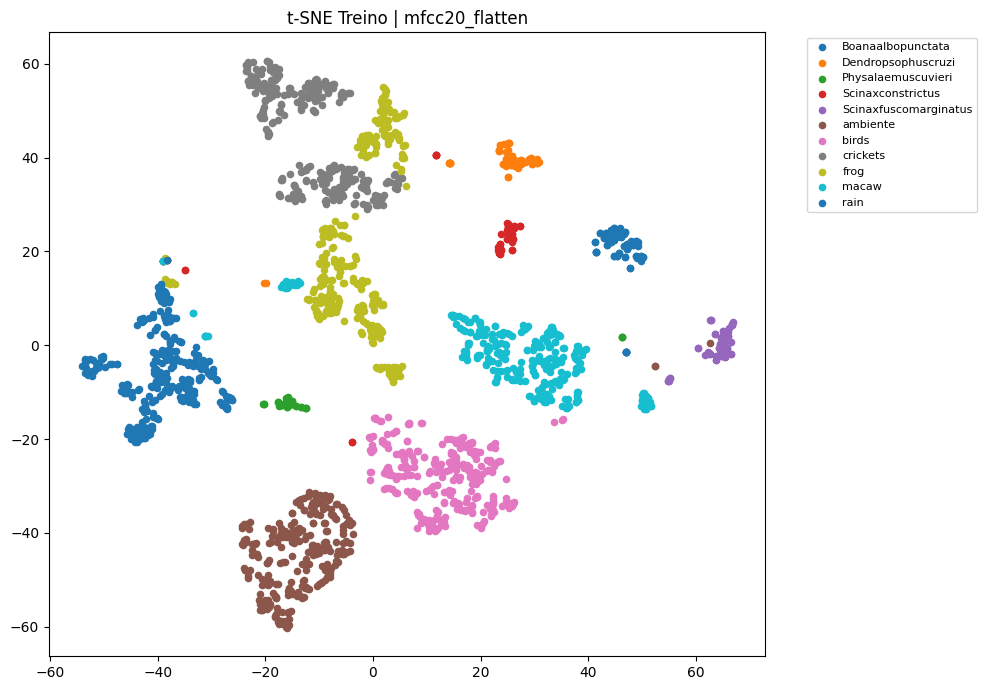

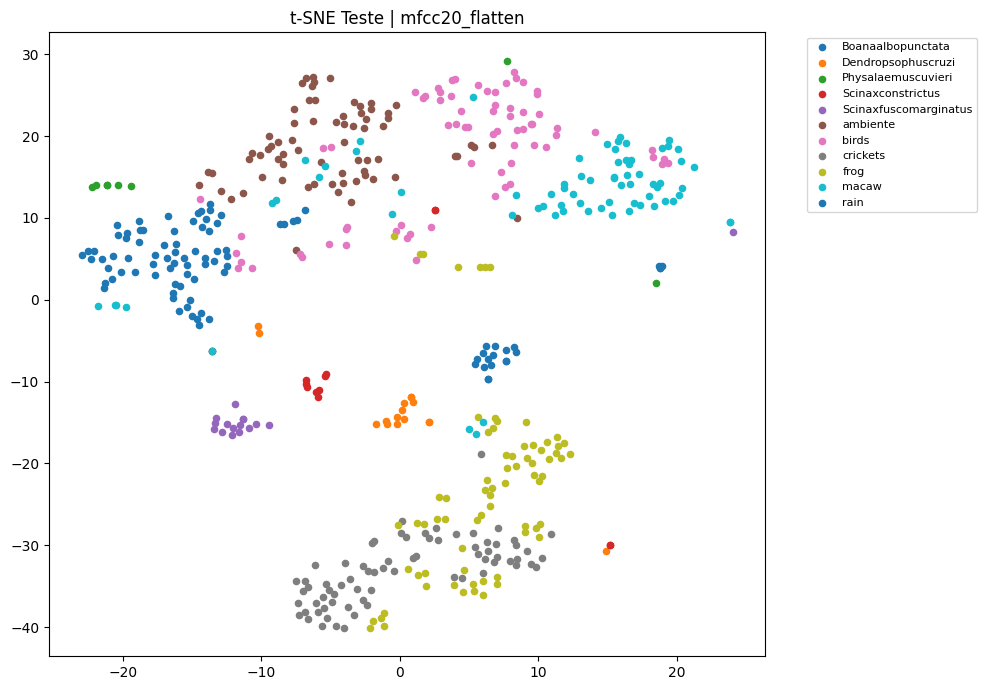

[mfcc20_flatten] Acurácia: 0.9167 | Silhueta treino: 0.4228 | Silhueta teste: 0.2033

──────────────────────────────────────────────────
Experimento: mfcc15_flatten
──────────────────────────────────────────────────


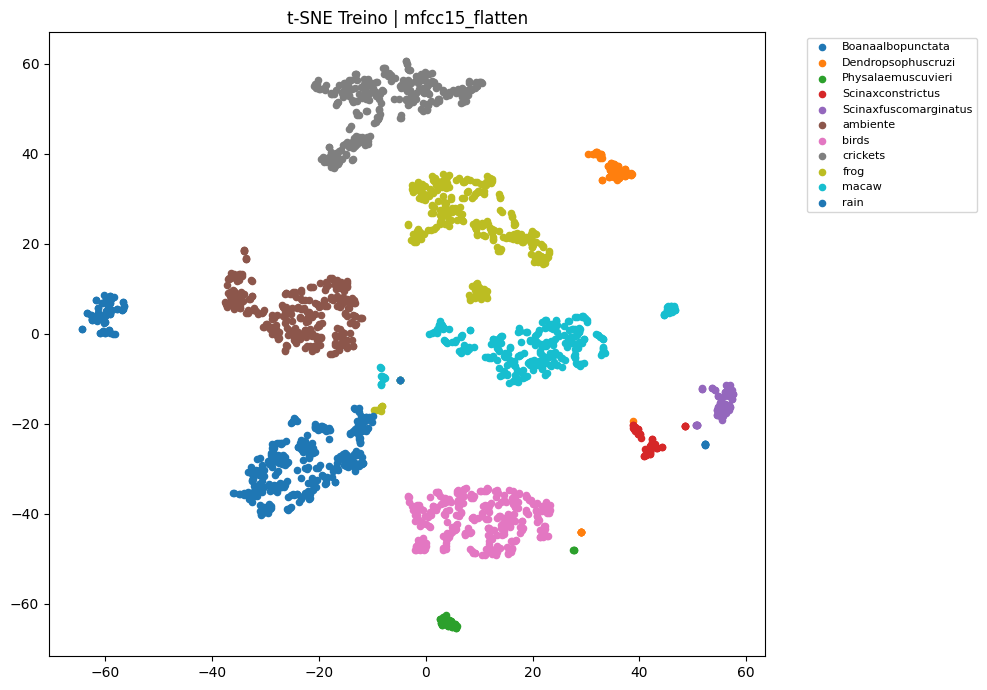

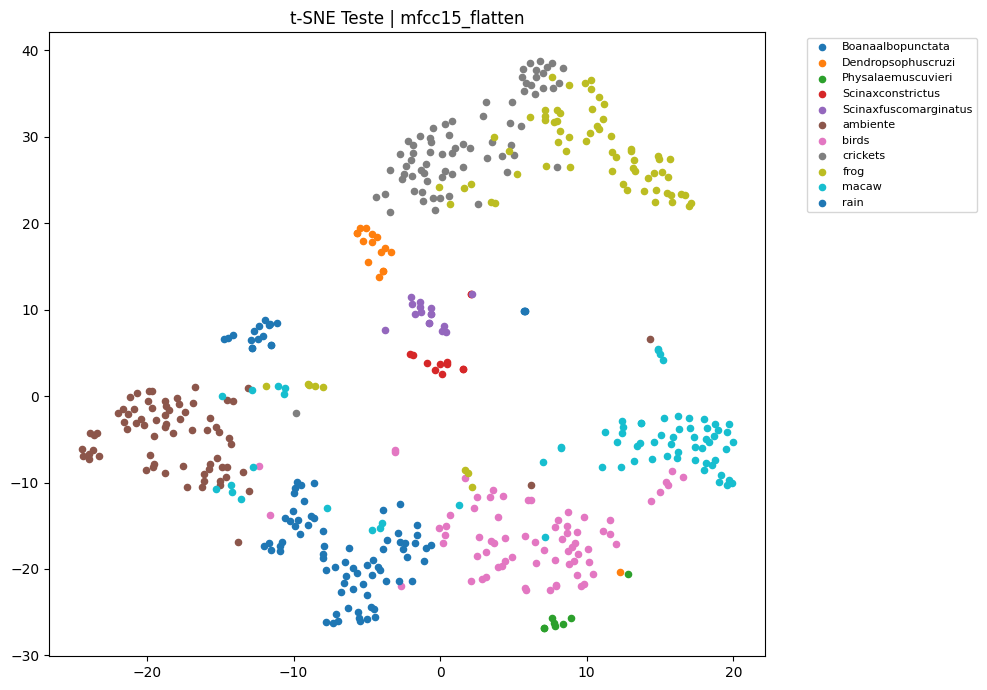

[mfcc15_flatten] Acurácia: 0.9306 | Silhueta treino: 0.5447 | Silhueta teste: 0.2700

──────────────────────────────────────────────────
Experimento: mfcc13_flatten
──────────────────────────────────────────────────


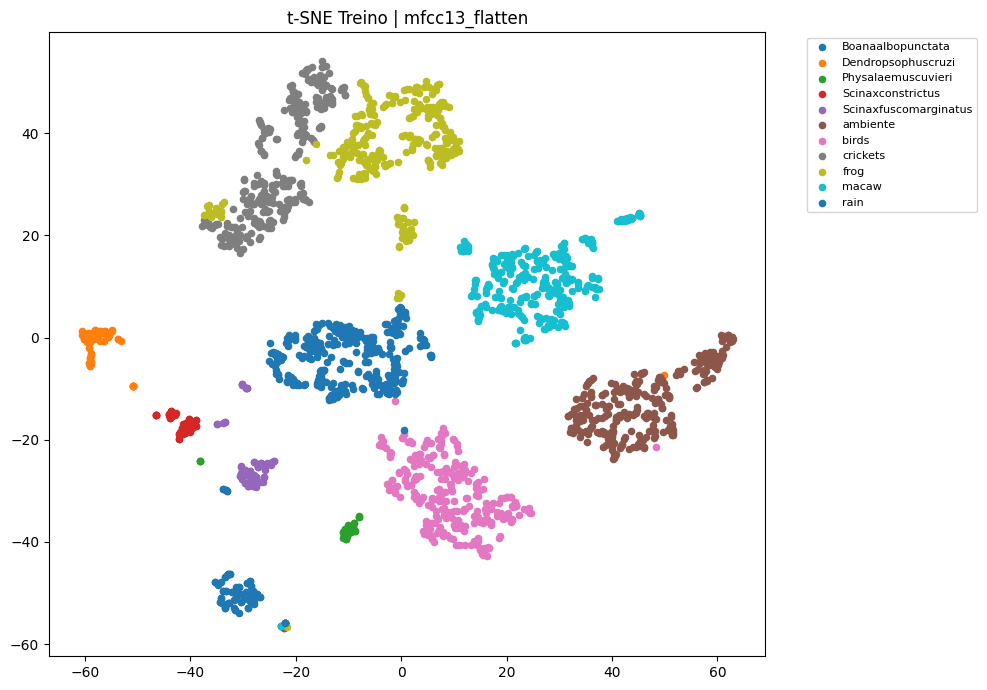

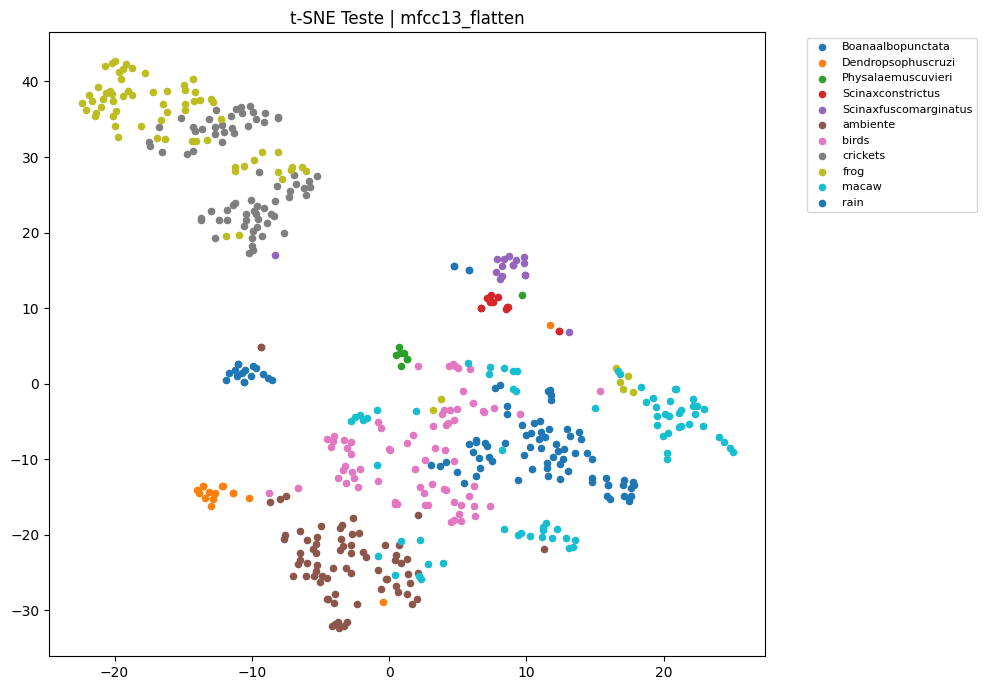

[mfcc13_flatten] Acurácia: 0.9246 | Silhueta treino: 0.4915 | Silhueta teste: 0.1888

──────────────────────────────────────────────────
Experimento: mfcc10_flatten
──────────────────────────────────────────────────


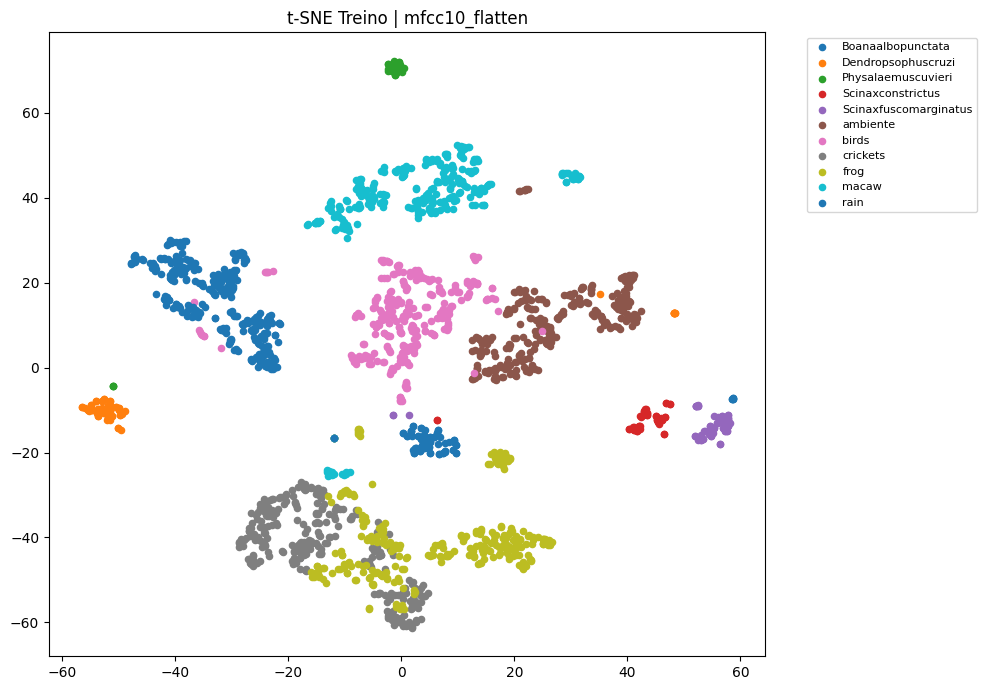

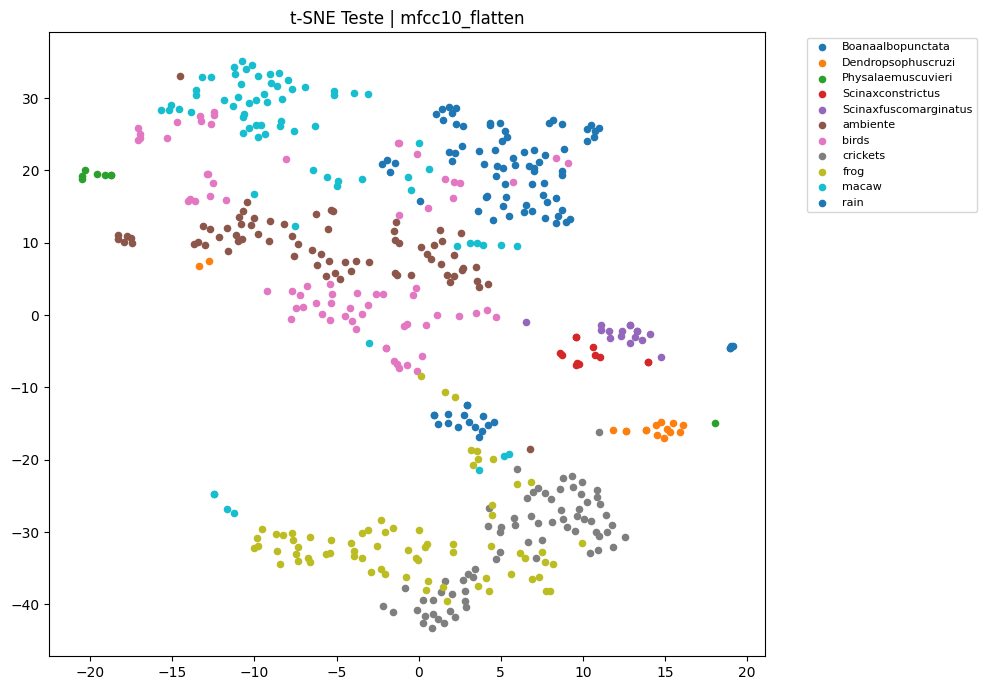

[mfcc10_flatten] Acurácia: 0.8433 | Silhueta treino: 0.3711 | Silhueta teste: 0.1577

──────────────────────────────────────────────────
Experimento: mfcc5_flatten
──────────────────────────────────────────────────


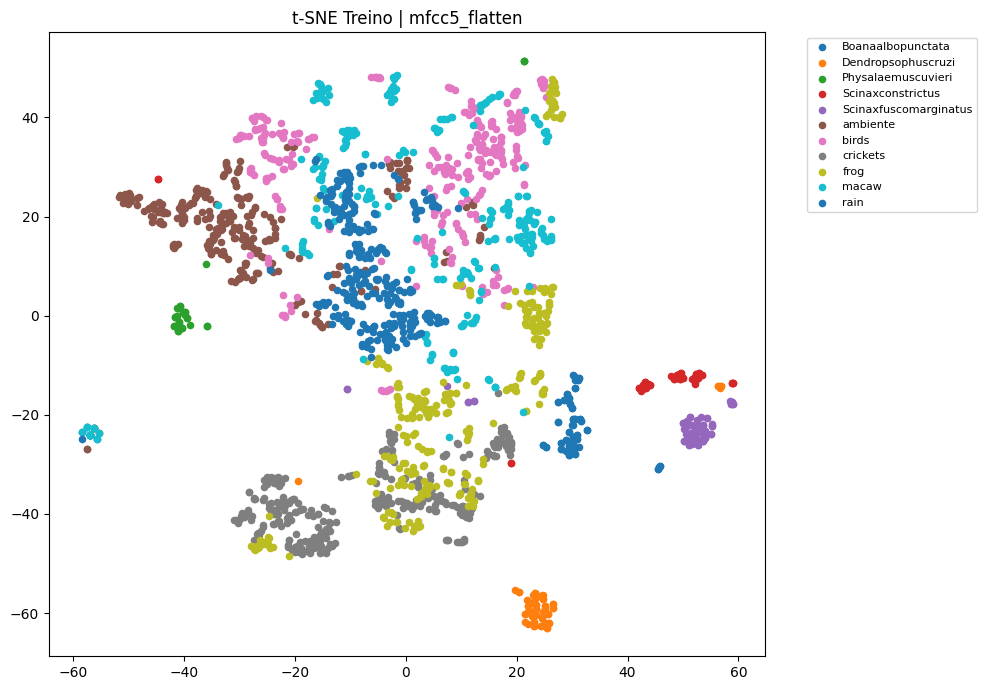

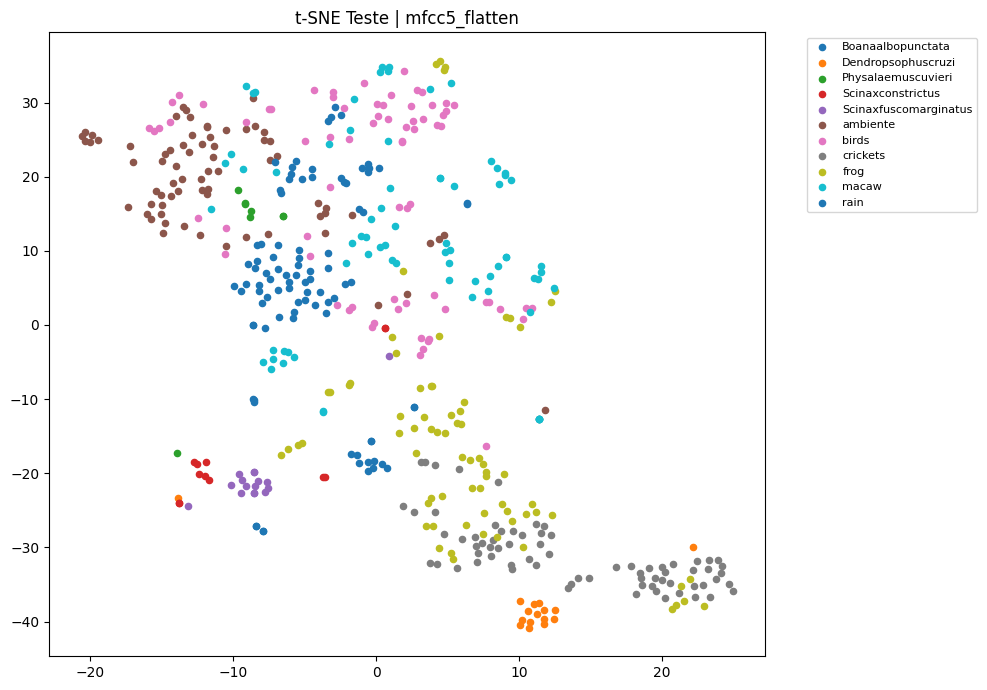

[mfcc5_flatten] Acurácia: 0.7520 | Silhueta treino: 0.1125 | Silhueta teste: -0.0218

──────────────────────────────────────────────────
Experimento: mfcc20_mean
──────────────────────────────────────────────────


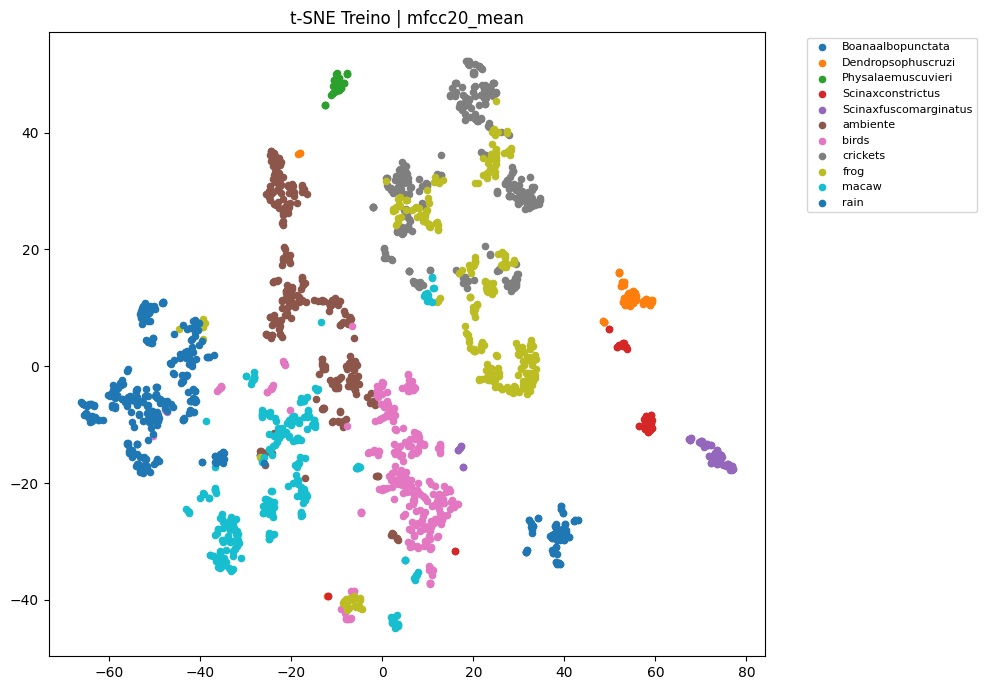

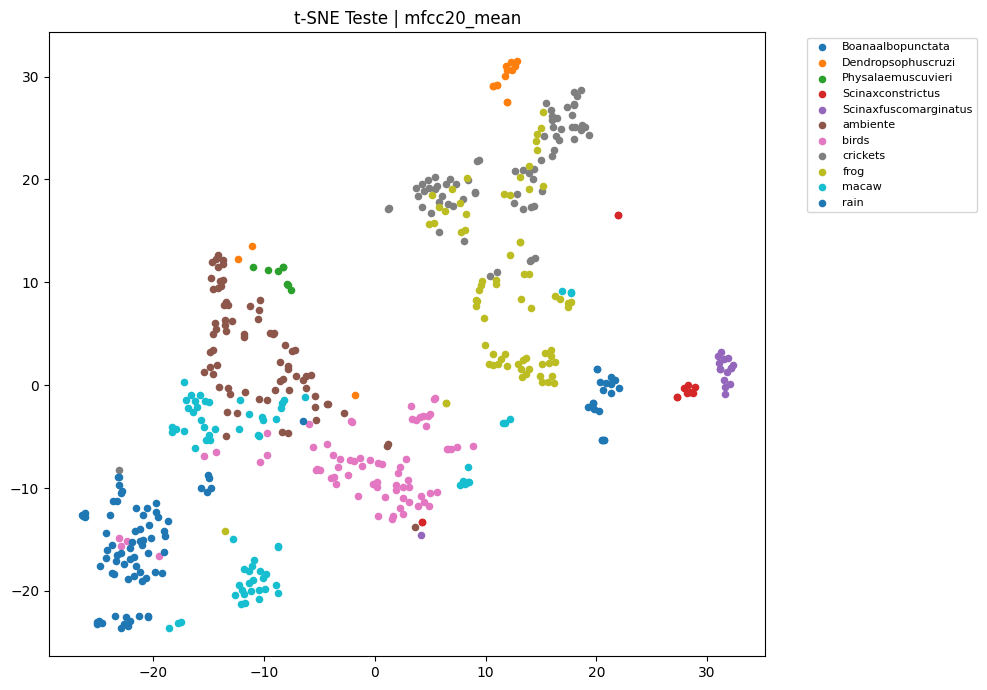

[mfcc20_mean] Acurácia: 0.9087 | Silhueta treino: 0.2757 | Silhueta teste: 0.1726

──────────────────────────────────────────────────
Experimento: mfcc15_mean
──────────────────────────────────────────────────


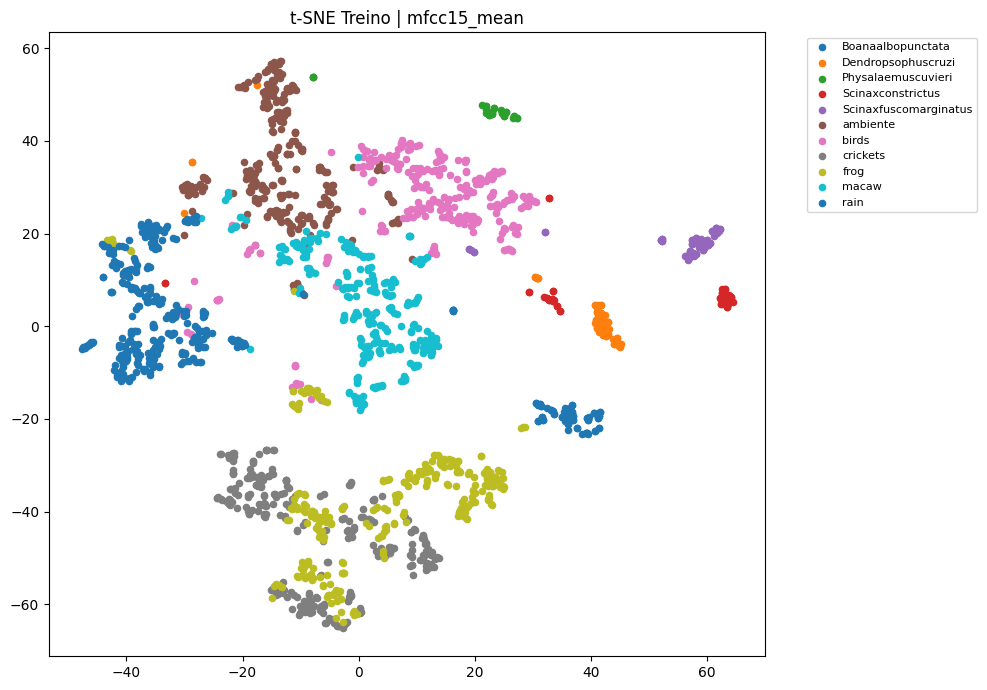

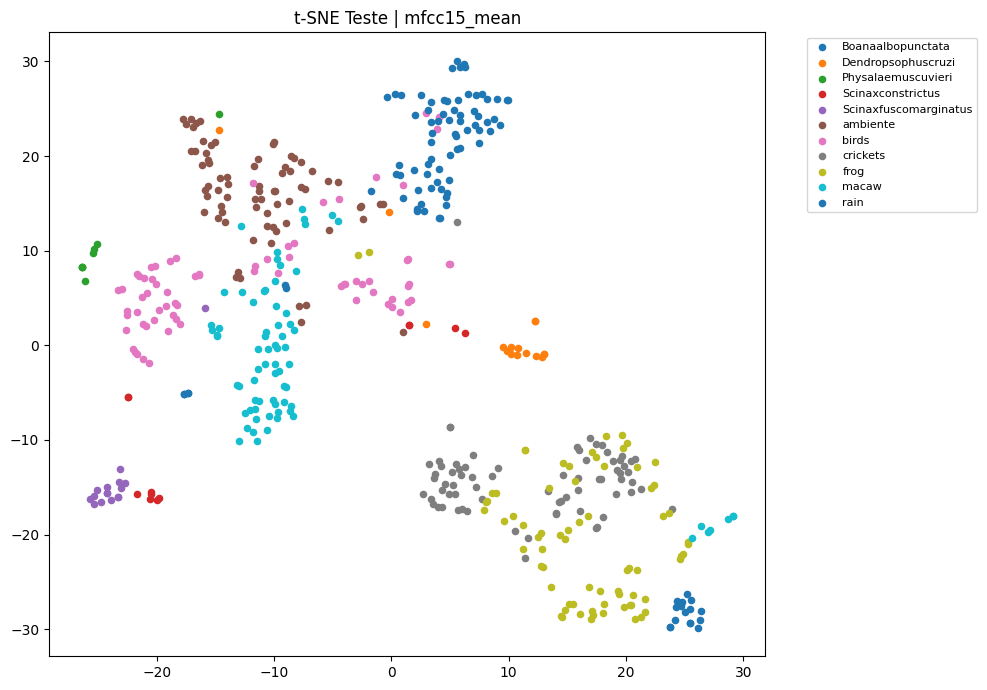

[mfcc15_mean] Acurácia: 0.9385 | Silhueta treino: 0.2712 | Silhueta teste: 0.1673

──────────────────────────────────────────────────
Experimento: mfcc13_mean
──────────────────────────────────────────────────


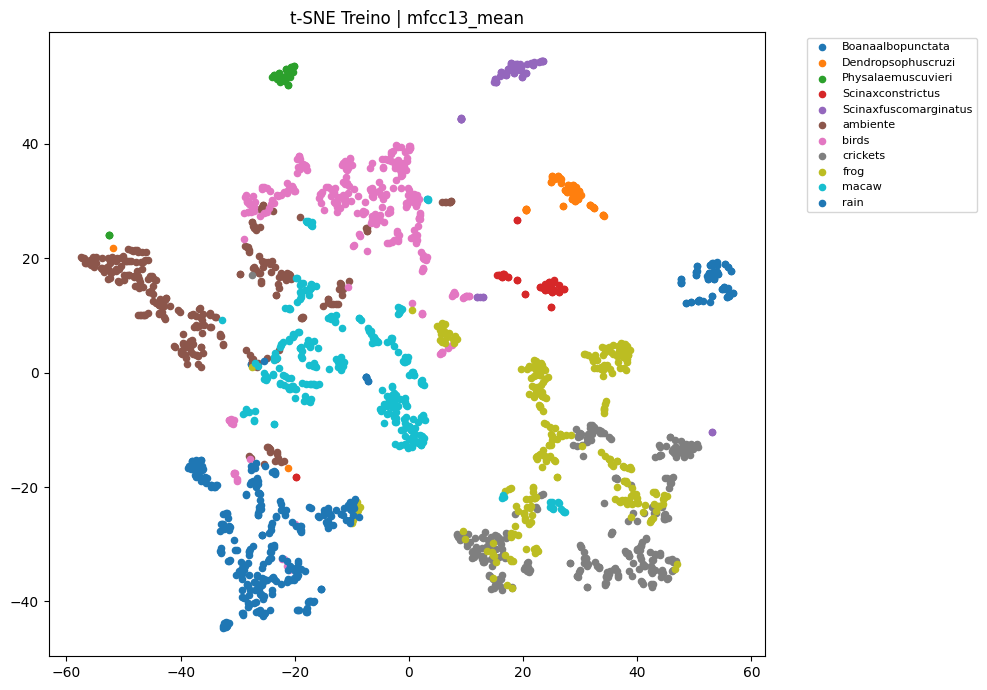

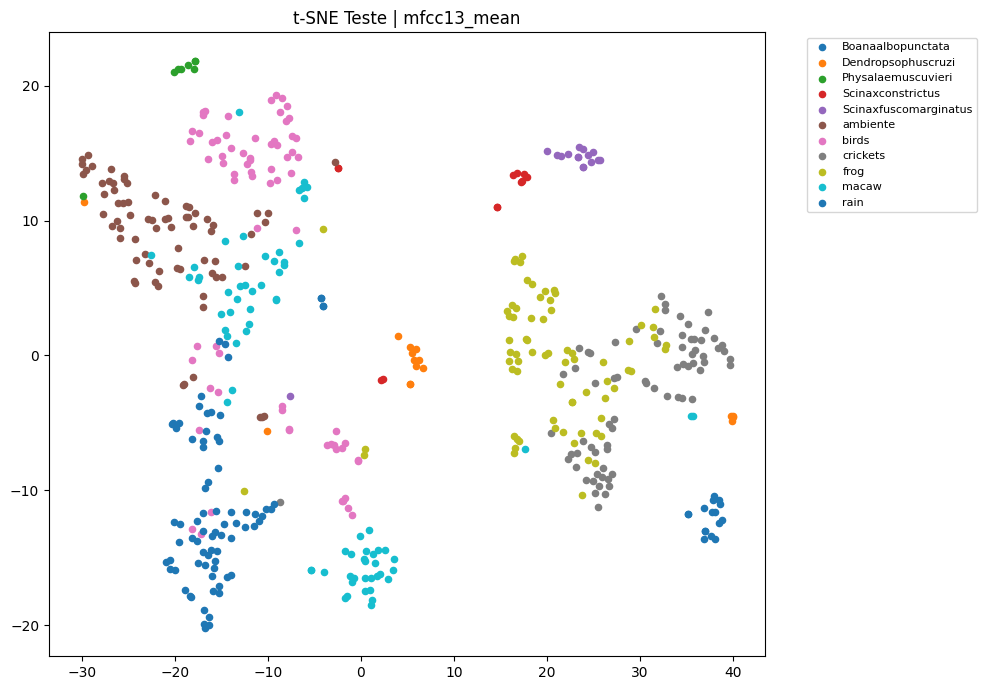

[mfcc13_mean] Acurácia: 0.8968 | Silhueta treino: 0.2781 | Silhueta teste: 0.1405

──────────────────────────────────────────────────
Experimento: mfcc10_mean
──────────────────────────────────────────────────


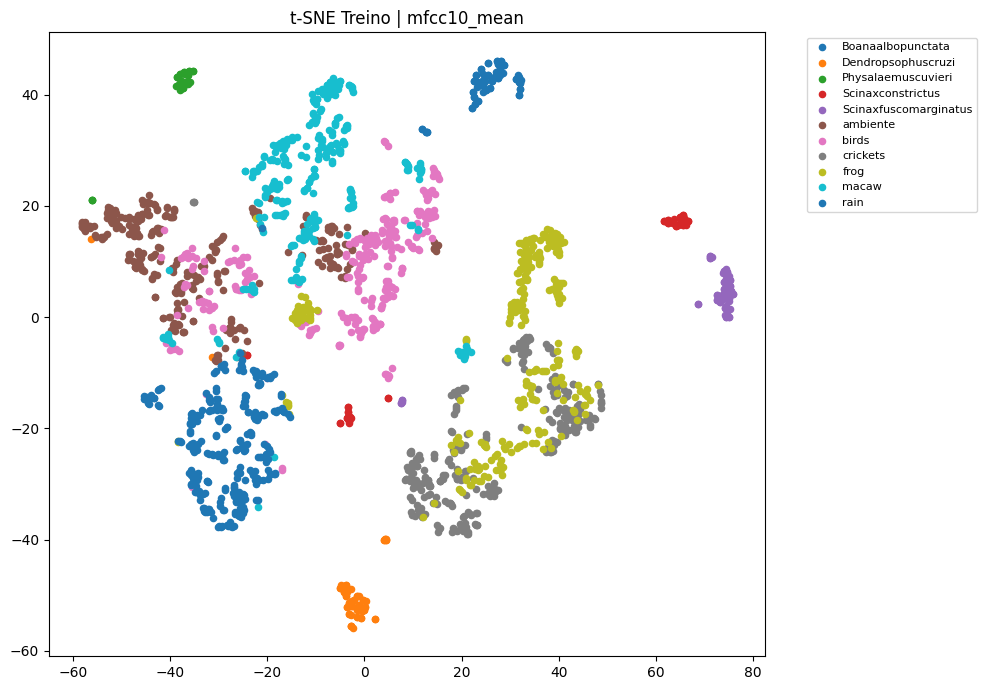

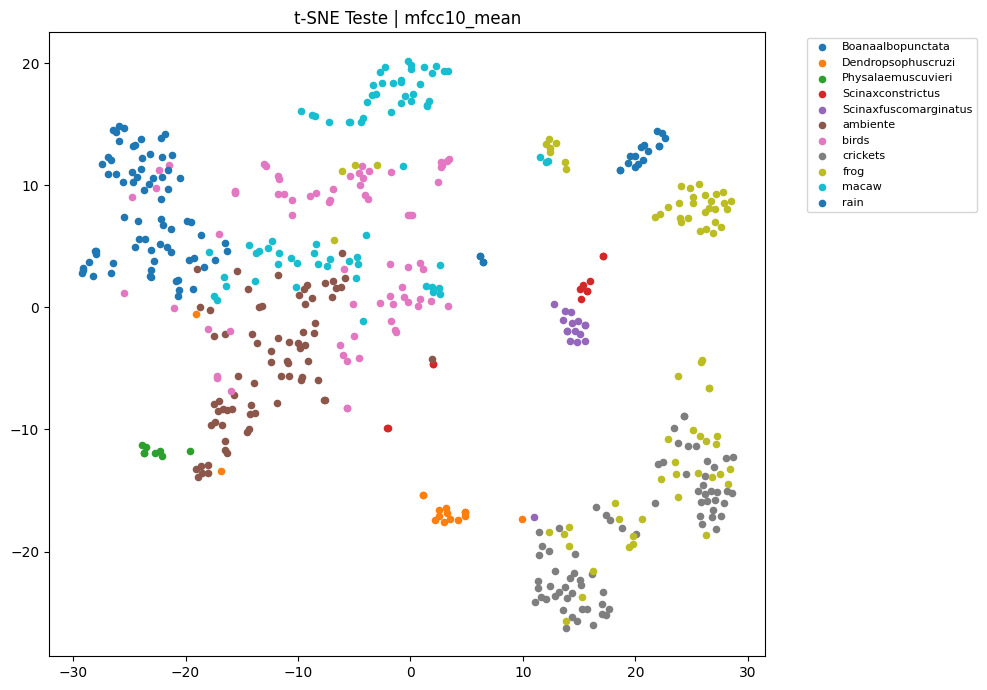

[mfcc10_mean] Acurácia: 0.9107 | Silhueta treino: 0.2263 | Silhueta teste: 0.1444

──────────────────────────────────────────────────
Experimento: mfcc5_mean
──────────────────────────────────────────────────


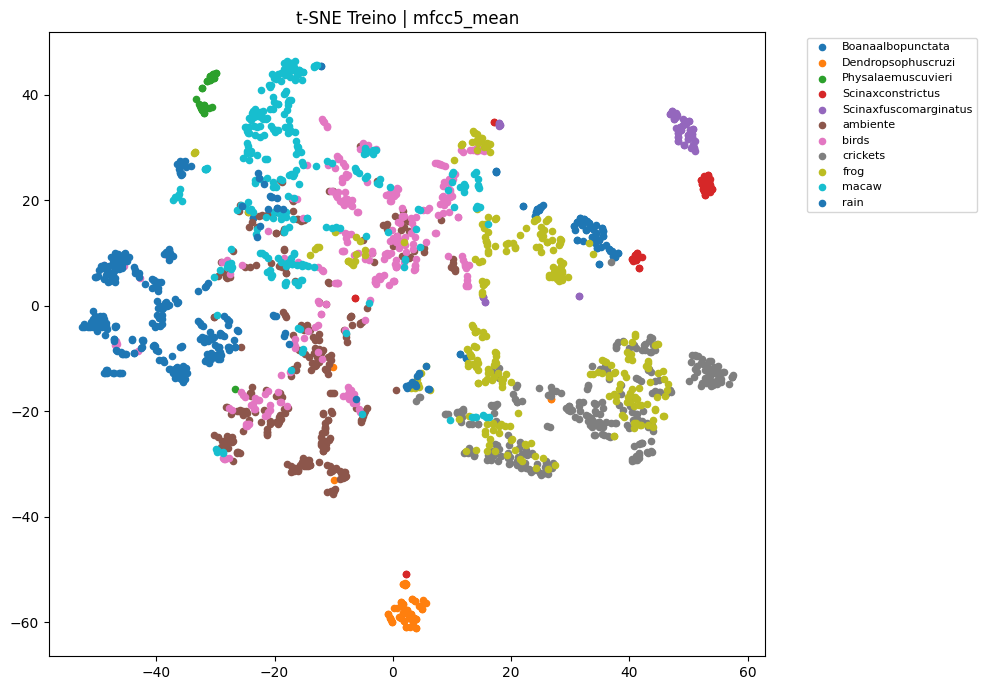

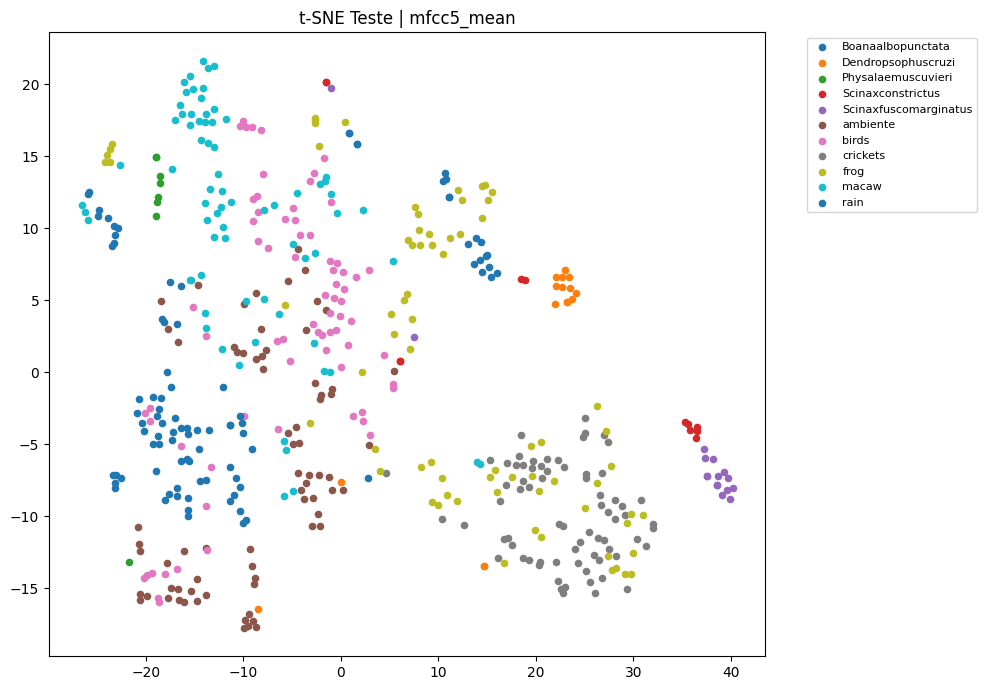

[mfcc5_mean] Acurácia: 0.7679 | Silhueta treino: 0.0963 | Silhueta teste: 0.0165

── Resumo dos experimentos ──
        config  accuracy  silhouette_train  silhouette_test
mfcc20_flatten  0.916667          0.422803         0.203280
mfcc15_flatten  0.930556          0.544696         0.269979
mfcc13_flatten  0.924603          0.491547         0.188849
mfcc10_flatten  0.843254          0.371058         0.157747
 mfcc5_flatten  0.751984          0.112549        -0.021752
   mfcc20_mean  0.908730          0.275653         0.172557
   mfcc15_mean  0.938492          0.271175         0.167304
   mfcc13_mean  0.896825          0.278113         0.140540
   mfcc10_mean  0.910714          0.226268         0.144384
    mfcc5_mean  0.767857          0.096263         0.016472


In [11]:

if __name__ == "__main__":

    df_experiments = pd.read_pickle("./mffcs-esc.pkl")
    df_results = run_all_experiments(df_experiments, label_col="labels")

    df_results.to_csv("treinamento-tsne.csv")